# 00 - EDA & Feature Sandbox (Bắt buộc)

Notebook này phục vụ mục đích:
1. Khám phá dữ liệu (EDA) trên tập mẫu (sample).
2. Đánh giá độ quan trọng và mức độ đóng đóng góp của các feature.
3. Tinh chỉnh danh sách feature trước khi đưa vào pipeline ETL chính thức (Notebook 01).

**Nguyên tắc:** Notebook-thin, gọi các helper từ `src/` để xử lý.

In [6]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to sys.path
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd] + list(cwd.parents) if (p / 'src').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.pipelines.notebook01_etl import DEFAULT_CORRIDOR_IDS

## 1. Cấu hình lấy dữ liệu mẫu

In [7]:
START_DATE = '2026-03-25'
END_DATE = '2026-04-26'
CORRIDOR_IDS = DEFAULT_CORRIDOR_IDS[:2]  # Lấy 2 hành lang làm mẫu

print(f"Lấy dữ liệu từ {START_DATE} đến {END_DATE} cho hành lang: {CORRIDOR_IDS}")

Lấy dữ liệu từ 2026-03-25 đến 2026-04-26 cho hành lang: [14146616491042222, 73904187376705400]


## 2. Tải dữ liệu từ Mart/Warehouse

In [8]:
# Ở bước này, ta chỉ load mẫu để phân tích nhanh
# Trong thực tế, notebook 01 sẽ lo việc ETL full volume
from src.data_access.warehouse_repository import get_segments_in_corridor
from src.data_access.forecast_mart_repository import load_forecast_mart_by_segments
from src.core.database import get_engine

engine = get_engine()
all_segments = []
for cid in CORRIDOR_IDS:
    # get_segments_in_corridor trả về danh sách segment_key
    segments = get_segments_in_corridor(cid)
    all_segments.extend(segments)

sample_segments = list(set(all_segments))[:20] # Lấy 20 segment tiêu biểu, duy nhất

df = load_forecast_mart_by_segments(
    engine=engine,
    segment_ids=sample_segments,
    start_date=START_DATE,
    end_date=END_DATE
)

print(f"Đã tải {len(df)} dòng dữ liệu mẫu cho {len(sample_segments)} segments.")
df.head()

Đã tải 13053 dòng dữ liệu mẫu cho 20 segments.


,segment_key,timestamp,current_speed_kmh,traffic_index,delay_seconds,quality_flag,congestion_level,default_lane_count,free_flow_speed_kmh,tomtom_frc,...,day_of_week,shift_code,is_one_way,is_peak_hour,is_business_hours,is_weekend,speed_ratio,speed_delta,time_sin,time_cos
0,35977559166783497,2026-04-12 05:05:08.855368,35.0,0.0,0.0,9,0,2,35.0,2,...,7,NIGHT,1,0,0,1,1.0,0.0,0.971342,0.237686
1,35977559166783497,2026-04-12 05:19:21.143246,35.0,0.0,0.0,9,0,2,35.0,2,...,7,NIGHT,1,0,0,1,1.0,0.0,0.984041,0.177944
2,35977559166783497,2026-04-12 05:37:52.664467,35.0,0.0,0.0,9,0,2,35.0,2,...,7,NIGHT,1,0,0,1,1.0,0.0,0.994969,0.100188
3,35977559166783497,2026-04-12 06:08:09.120442,48.0,0.0,0.0,9,0,2,48.0,2,...,7,EARLY_MORNING,1,1,0,1,1.0,13.0,0.999391,-0.034899
4,35977559166783497,2026-04-12 06:37:52.814061,35.0,0.0,0.0,9,0,2,35.0,2,...,7,EARLY_MORNING,1,1,0,1,1.0,-13.0,0.986996,-0.160743


## 3. Phân tích đặc trưng (Feature Analysis)

**Lưu ý quan trọng về Model Alignment:**
Để mô phỏng đúng điều kiện thực tế, ta thiết lập phân tích như sau:
- **Target (Nhãn):** Mức độ ùn tắc tại thời điểm $T$.
- **Context Features (Biến bối cảnh):** Các đặc trưng tại thời điểm $T$ (Weather, Time, v.v.) vì chúng có thể dự đoán hoặc biết trước.
- **Dynamic Features (Biến động lực):** Sử dụng dữ liệu quá khứ từ **$T-15m$ đến $T-180m$** (12 bước trễ). 
**Tuyệt đối không sử dụng Dynamic Feature tại thời điểm $T$** để tránh rò rỉ dữ liệu, vì tại thời điểm cần ra quyết định dự báo cho 15p tới, ta chưa có dữ liệu tốc độ/delay của chính khung giờ đó.

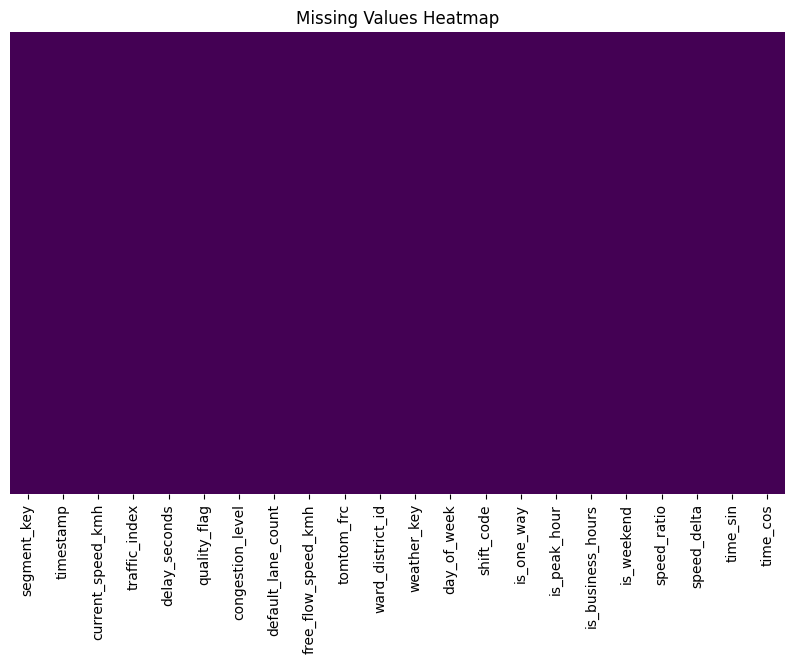

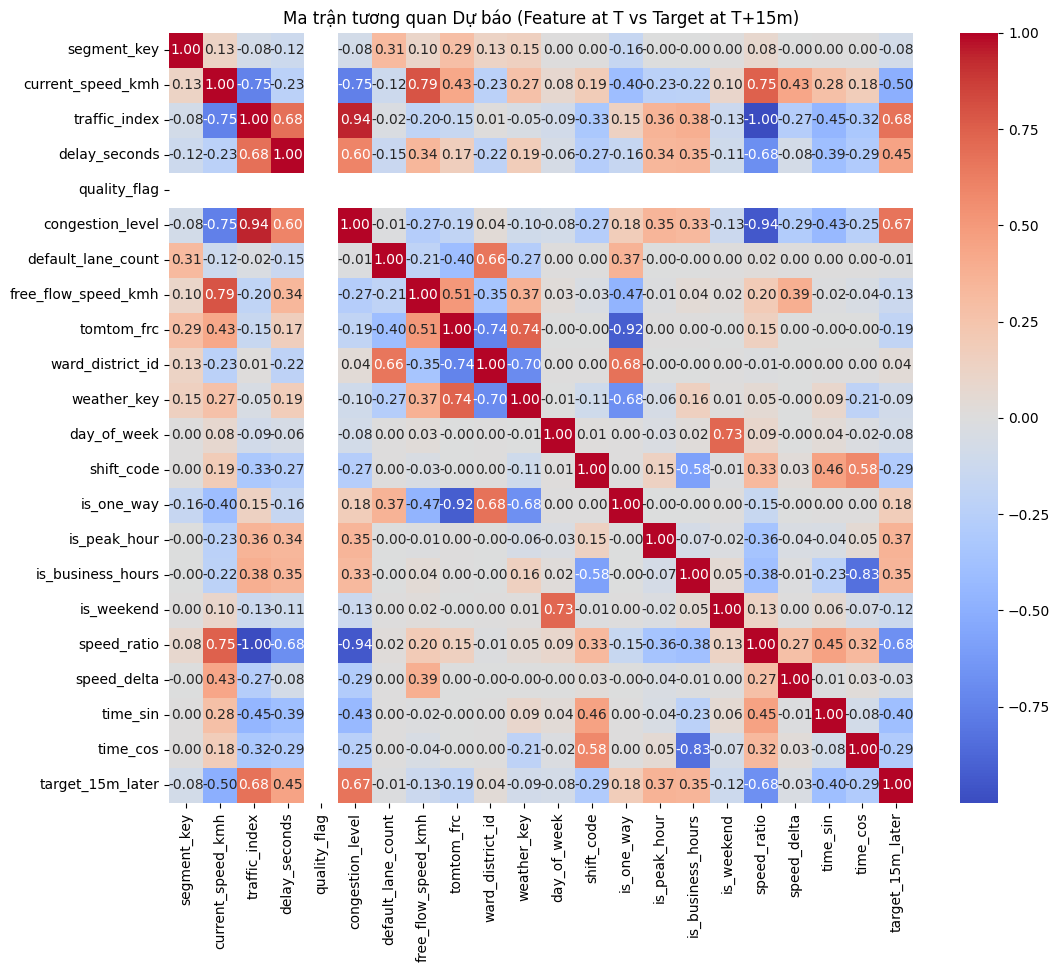


Tương quan cụ thể với nhãn 15 phút sau:
                     target_15m_later
target_15m_later             1.000000
traffic_index                0.677811
congestion_level             0.667705
delay_seconds                0.445923
is_peak_hour                 0.365942
is_business_hours            0.346822
is_one_way                   0.181728
ward_district_id             0.035408
default_lane_count          -0.010779
speed_delta                 -0.033408
day_of_week                 -0.077446
segment_key                 -0.081874
weather_key                 -0.090213
is_weekend                  -0.122011
free_flow_speed_kmh         -0.130144
tomtom_frc                  -0.189216
time_cos                    -0.289680
shift_code                  -0.291678
time_sin                    -0.395537
current_speed_kmh           -0.504900
speed_ratio                 -0.678382
quality_flag                      NaN


In [9]:
# 3.1 Kiểm tra Missing Values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# 3.2 Tương quan Dự báo (Predictive Correlation)
# Vì mục tiêu là dự báo cho 15 phút sau, ta cần dịch chuyển nhãn (Shift Target)
from sklearn.preprocessing import LabelEncoder

df_eda = df.copy().sort_values(['segment_key', 'timestamp'])

# Tạo nhãn tương lai (shift -1 có nghĩa là lấy giá trị của dòng tiếp theo đưa vào dòng hiện tại)
# Lưu ý: Phải groupby theo segment để tránh nhầm lẫn giữa các đoạn đường khác nhau
df_eda['target_15m_later'] = df_eda.groupby('segment_key')['congestion_level'].shift(-1)

# Encode categorical để tính toán
categorical_cols = ['ward_district_id', 'shift_code', 'day_of_week', 'weather_key', 'tomtom_frc']
le = LabelEncoder()
for col in categorical_cols:
    if col in df_eda.columns:
        df_eda[col] = le.fit_transform(df_eda[col].astype(str))

# Loại bỏ các dòng cuối của mỗi segment (vì shift -1 sẽ tạo ra giá trị NaN ở dòng cuối)
df_eda = df_eda.dropna(subset=['target_15m_later'])

# Tính toán ma trận tương quan
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
corr = df_eda[numeric_cols].corr()

# Tập trung vào tương quan với nhãn tương lai
target_corr = corr[['target_15m_later']].sort_values(by='target_15m_later', ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan Dự báo (Feature at T vs Target at T+15m)")
plt.show()

print("\nTương quan cụ thể với nhãn 15 phút sau:")
print(target_corr)

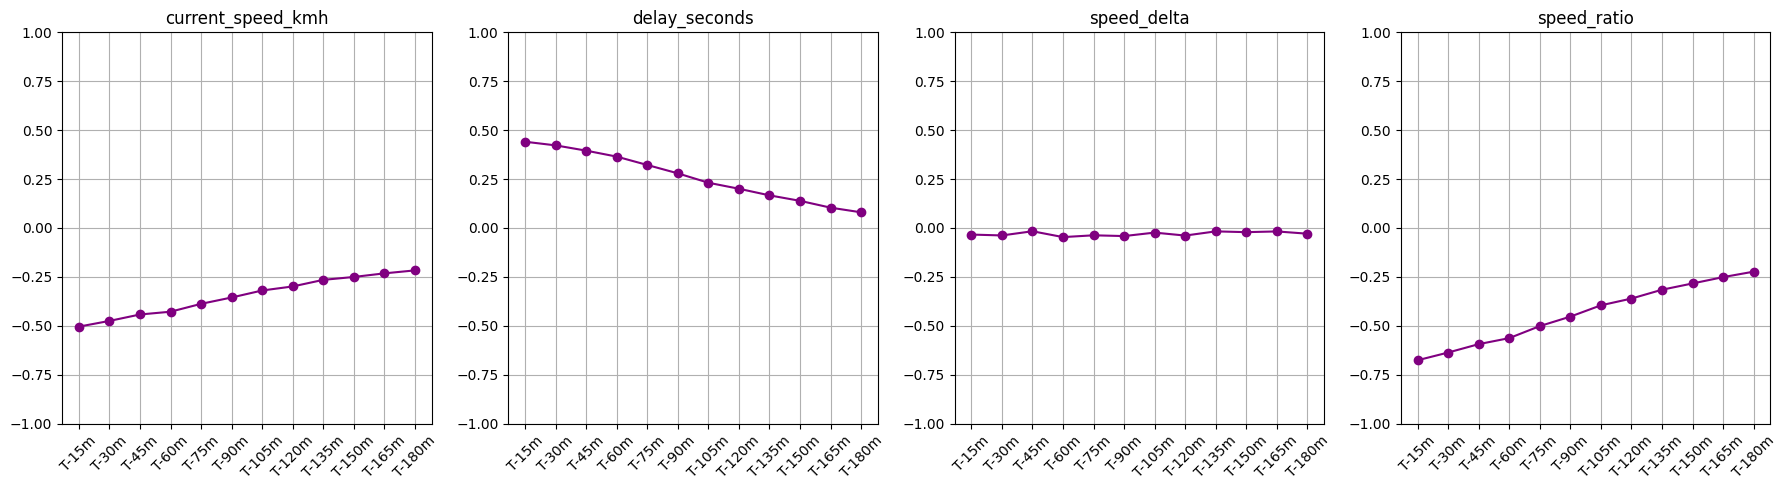

In [10]:
# 3.3 Phân tích mức độ suy giảm tương quan theo thời gian (History: T-15m -> T-180m)
from sklearn.preprocessing import LabelEncoder

# --- BƯỚC 1: KHỞI TẠO DỮ LIỆU CHUỖI (df_seq) ---
dynamic_features = ['current_speed_kmh', 'delay_seconds', 'speed_delta', 'speed_ratio']
n_lags = 12

df_seq = df.copy().sort_values(['segment_key', 'timestamp'])
df_seq['target_current'] = df_seq['congestion_level'] # Nhãn tại T

lagged_cols = []
for feat in dynamic_features:
    for lag in range(1, n_lags + 1):
        col_name = f"{feat}_lag_{lag}"
        df_seq[col_name] = df_seq.groupby('segment_key')[feat].shift(lag)
        lagged_cols.append(col_name)

current_context_cols = ['ward_district_id', 'shift_code', 'day_of_week', 'weather_key', 'is_peak_hour']
for col in current_context_cols:
    if col in df_seq.columns:
        df_seq[col] = LabelEncoder().fit_transform(df_seq[col].astype(str))

df_seq = df_seq.dropna(subset=lagged_cols)

# --- BƯỚC 2: VẼ BIỂU ĐỒ TƯƠNG QUAN ---
plt.figure(figsize=(18, 5))
for i, feat in enumerate(dynamic_features):
    lags = [f"{feat}_lag_{lag}" for lag in range(1, n_lags + 1)]
    corr_vals = [df_seq[[col, 'target_current']].corr().iloc[0, 1] for col in lags]
    
    plt.subplot(1, 4, i+1)
    plt.plot(range(1, n_lags + 1), corr_vals, marker='o', color='purple')
    plt.xticks(range(1, n_lags + 1), [f"T-{l*15}m" for l in range(1, n_lags + 1)], rotation=45)
    plt.title(f"{feat}")
    plt.grid(True)
    plt.ylim(-1, 1)

plt.tight_layout()
plt.show()


## 4. Đánh giá mức độ quan trọng (Feature Importance - Sơ bộ)

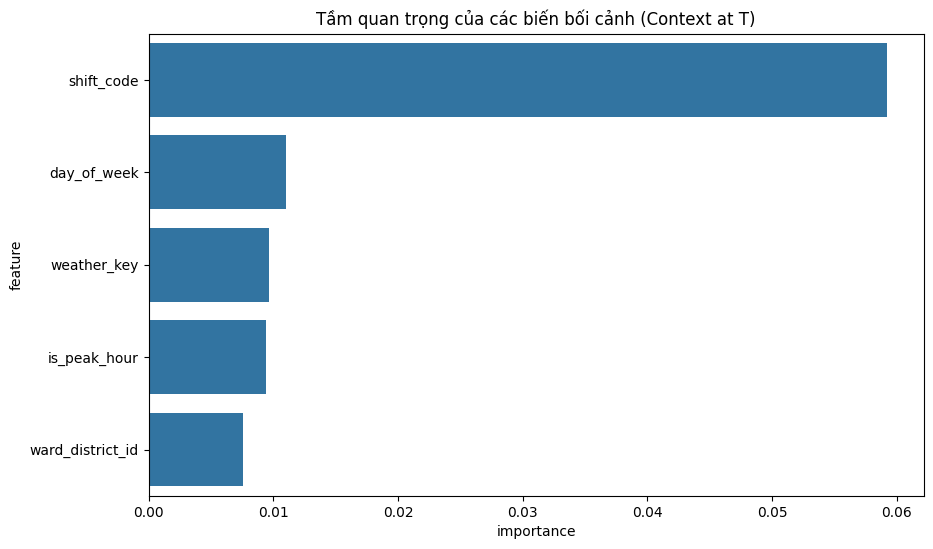

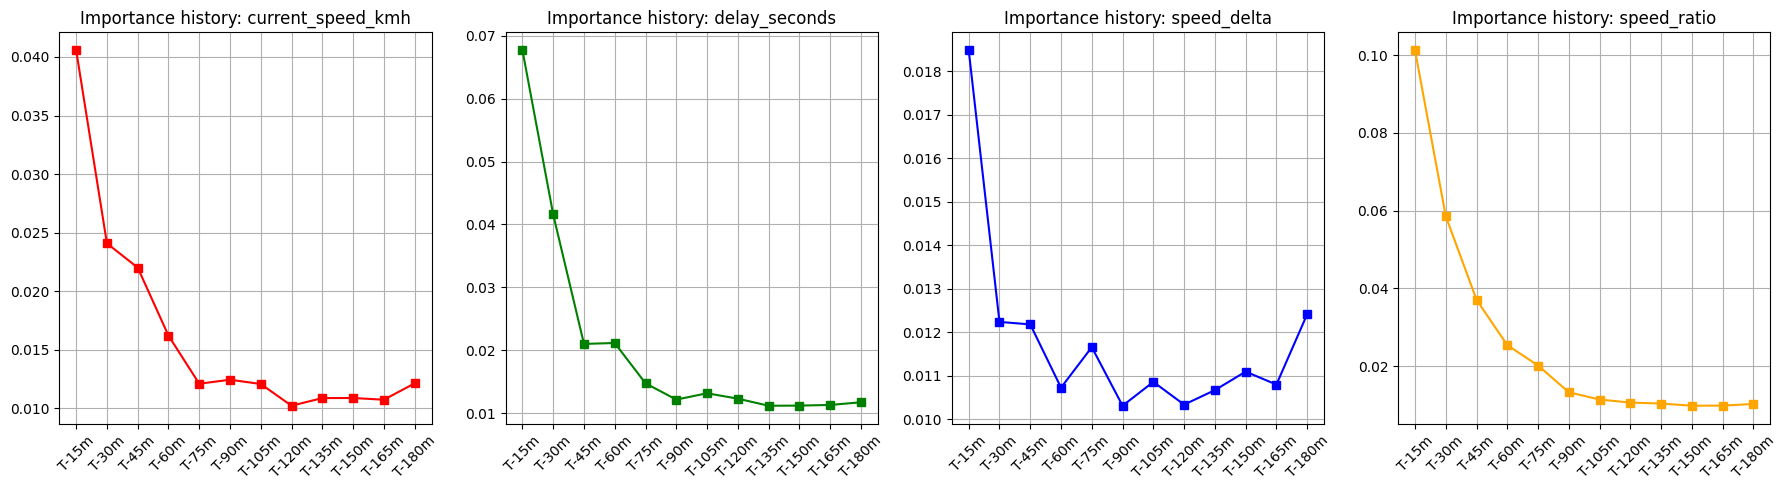

In [11]:
from sklearn.ensemble import RandomForestClassifier

# 4. Đánh giá Tầm quan trọng (Feature Importance)
if 'df_seq' in locals():
    X = df_seq[lagged_cols + current_context_cols].copy()
    y = df_seq['target_current'].astype(int)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    importance_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
    
    # Bar chart cho context features
    ctx_features = importance_df[importance_df['feature'].isin(current_context_cols)].sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=ctx_features)
    plt.title("Tầm quan trọng của các biến bối cảnh (Context at T)")
    plt.show()
    
    # Line charts cho Dynamic history (T-15m -> T-180m)
    plt.figure(figsize=(18, 5))
    colors = ['r', 'g', 'b', 'orange']
    for i, feat in enumerate(dynamic_features):
        feat_imps = []
        for lag in range(1, n_lags + 1):
            col_name = f"{feat}_lag_{lag}"
            imp_val = importance_df[importance_df['feature'] == col_name]['importance'].values[0]
            feat_imps.append(imp_val)
        
        plt.subplot(1, 4, i+1)
        plt.plot(range(1, n_lags + 1), feat_imps, marker='s', color=colors[i])
        plt.xticks(range(1, n_lags + 1), [f"T-{l*15}m" for l in range(1, n_lags + 1)], rotation=45)
        plt.title(f"Importance history: {feat}")
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Vui lòng chạy Cell 3.3 trước.")

## 5. Kết luận & Tinh chỉnh

Dựa trên phân tích Tầm quan trọng (Feature Importance) và tương quan, ta quyết định tinh chỉnh bộ tính năng như sau:

**1. Danh sách Feature loại bỏ:**
- `quality_flag`: Ít biến động hoặc không đóng góp đáng kể vào mô hình.
- `default_lane_count`: Thông tin tĩnh không giúp phân biệt mức độ ùn tắc linh hoạt.
- `traffic_index`: Có độ tương quan quá cao với speed hoặc không mang lại thông tin mới.

**2. Danh sách Feature giữ lại đặc biệt:**
- `speed_ratio`: Được giữ lại để đánh giá tương quan giữa vận tốc hiện tại và vận tốc tự do (free-flow).

**3. Quyết định:**
- Đã cập nhật `src/ml/feature_contract.py` để phản ánh các thay đổi trên.
- Notebook 01 (ETL) sẽ tự động áp dụng contract mới này.

**Hành động tiếp theo:** Chạy lại Notebook 01 để làm sạch tập dữ liệu chuẩn bị cho huấn luyện RL.